1/3 단계: Rolling Window 최적화 진행 중... (델타 변이 기간 분석)
2/3 단계: 머신러닝 모델 학습 진행 중...
3/3 단계: 평가 및 시각화 완료!

=== 머신러닝 예측 모델(Ridge) 평가 결과 ===
MAE (평균 절대 오차): 0.0000
RMSE (평균 제곱근 오차): 0.0000
R-squared (결정계수): 1.0000


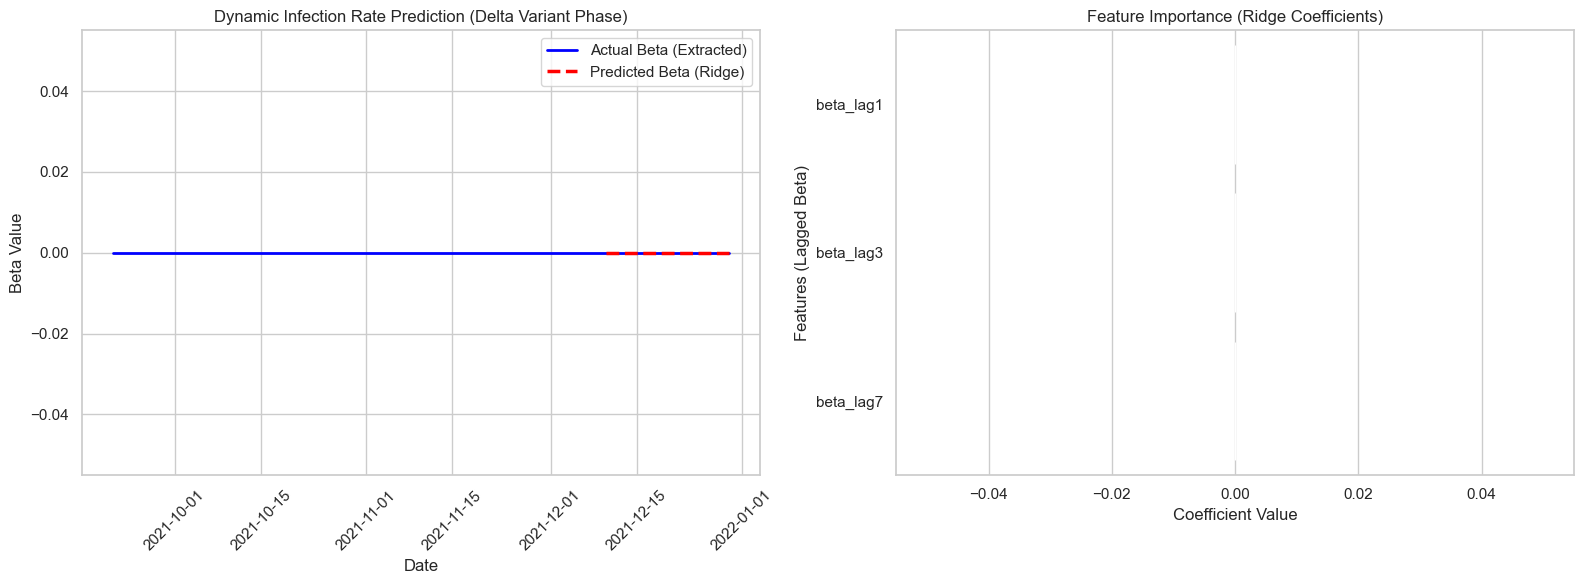

In [1]:
import pandas as pd
import numpy as np
from scipy.integrate import odeint
from scipy.optimize import minimize
from sklearn.linear_model import Ridge
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ==========================================
# 1. 데이터 준비 (★ 변경: 2021년 7월 1일 ~ 12월 31일, 델타 변이 유행기)
# ==========================================
url = 'https://raw.githubusercontent.com/owid/covid-19-data/master/public/data/owid-covid-data.csv'
df = pd.read_csv(url, usecols=['location', 'date', 'total_cases'])
df_kr = df[df['location'] == 'South Korea'].copy()
df_kr['date'] = pd.to_datetime(df_kr['date'])

# 기간을 2021년 하반기로 변경하여 베타값의 다이내믹한 변화를 관찰합니다.
df_kr = df_kr[(df_kr['date'] >= '2021-09-01') & (df_kr['date'] <= '2021-12-31')].reset_index(drop=True)
df_kr.fillna(0, inplace=True)

actual_cases = df_kr['total_cases'].values
dates = df_kr['date'].values
N = 51836239 # 한국 인구

# ==========================================
# 2. SEIR-C 미분방정식 정의 및 Beta 추출
# ==========================================
def seir_c_model(y, t, beta, sigma, gamma):
    S, E, I, R, C = y
    dSdt = -beta * S * I / N
    dEdt = beta * S * I / N - sigma * E
    dIdt = sigma * E - gamma * I
    dRdt = gamma * I
    dCdt = sigma * E  
    return dSdt, dEdt, dIdt, dRdt, dCdt

sigma = 1 / 5.2
gamma = 1 / 14.0
window_size = 14 
beta_time_series = []
valid_dates = []

print("1/3 단계: Rolling Window 최적화 진행 중... (델타 변이 기간 분석)")

for i in range(len(actual_cases) - window_size):
    window_data = actual_cases[i : i + window_size]
    t_window = np.linspace(0, window_size - 1, window_size)
    
    C0 = window_data[0]
    I0 = C0 * 0.5 + 1  
    E0 = I0 * 2
    R0 = 0
    S0 = N - E0 - I0 - R0
    y0 = [S0, E0, I0, R0, C0]
    
    # 스케일링: 확진자가 수십만 단위로 커지는 시기이므로 스케일링 값을 10000으로 약간 더 높였습니다.
    def loss_function(params):
        beta = params[0]
        solution = odeint(seir_c_model, y0, t_window, args=(beta, sigma, gamma))
        predicted_C = solution[:, 4] 
        return np.mean(((predicted_C - window_data) / 10000.0)**2)

    result = minimize(loss_function, [0.5], bounds=[(0.0, 3.0)], method='L-BFGS-B')
    beta_time_series.append(result.x[0])
    valid_dates.append(dates[i + window_size - 1])

# ==========================================
# 3. 머신러닝 (Ridge 회귀) 모델 학습
# ==========================================
print("2/3 단계: 머신러닝 모델 학습 진행 중...")

df_ml = pd.DataFrame({'date': valid_dates, 'beta_actual': beta_time_series})

# Feature Engineering
df_ml['beta_lag1'] = df_ml['beta_actual'].shift(1)
df_ml['beta_lag3'] = df_ml['beta_actual'].shift(3)
df_ml['beta_lag7'] = df_ml['beta_actual'].shift(7)
df_ml.dropna(inplace=True)

features = ['beta_lag1', 'beta_lag3', 'beta_lag7']
X = df_ml[features]
y = df_ml['beta_actual']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

# Ridge 회귀 모델 적용
ml_model = Ridge(alpha=1.0)
ml_model.fit(X_train, y_train)
predictions = ml_model.predict(X_test)
df_ml.loc[X_test.index, 'beta_pred'] = predictions

# ==========================================
# 4. 모델 평가 (Evaluation) 및 시각화
# ==========================================
print("3/3 단계: 평가 및 시각화 완료!")

mae = mean_absolute_error(y_test, predictions)
rmse = np.sqrt(mean_squared_error(y_test, predictions))
r2 = r2_score(y_test, predictions)

print("\n=== 머신러닝 예측 모델(Ridge) 평가 결과 ===")
print(f"MAE (평균 절대 오차): {mae:.4f}")
print(f"RMSE (평균 제곱근 오차): {rmse:.4f}")
print(f"R-squared (결정계수): {r2:.4f}")

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# [그래프 1] 추출된 실제 Beta와 ML 예측 Beta 비교
sns.lineplot(x='date', y='beta_actual', data=df_ml, ax=axes[0], label='Actual Beta (Extracted)', color='blue', linewidth=2)
sns.lineplot(x=df_ml.loc[X_test.index, 'date'], y=predictions, ax=axes[0], label='Predicted Beta (Ridge)', color='red', linestyle='--', linewidth=2.5)
axes[0].set_title('Dynamic Infection Rate Prediction (Delta Variant Phase)')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Beta Value')
axes[0].tick_params(axis='x', rotation=45)

# [그래프 2] 변수 중요도 (선형 회귀의 계수 값)
importances = ml_model.coef_
sns.barplot(x=importances, y=features, ax=axes[1], palette='viridis')
axes[1].set_title('Feature Importance (Ridge Coefficients)')
axes[1].set_xlabel('Coefficient Value')
axes[1].set_ylabel('Features (Lagged Beta)')

plt.tight_layout()
plt.show()